[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/research-assistant.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239974-lesson-4-research-assistant)

## Recipe Assistant


### Goal

**Recipe Generator Agent Summary**
 This project aims to develop a lightweight, agent system centered around chat models to personalize the research process.

  
`Planning`
* Users provide a topic, and the system generates a team of AI analysts, each focusing on one sub-topic.
* `Human-in-the-loop` will be used to refine these sub-topics before research begins.
  
`LLM Utilization`
* This dialogue will involve multiple exchanges to gather specific features for the final receipe.
* The discussions will be documented within `sub-graphs`, including their internal dynamics.



In [ ]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain_openai langchain_community langchain_core tavily-python wikipedia

## Setup

In [ ]:
# Imports
import os
import getpass

from langgraph.graph import StateGraph, START, END
from langchain.schema import SystemMessage
from langchain_openai import ChatOpenAI
from langchain.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

from IPython.display import Image, display

from typing import List, Dict
from langgraph.types import interrupt
from langgraph.types import Command
from pydantic import BaseModel
from typing import List
from pydantic import BaseModel, Field
from typing import Optional, Union
from pydantic import BaseModel, Field, validator

In [ ]:
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

os.environ["OPENAI_API_KEY"] = open_ai_key
os.environ["LANGCHAIN_API_KEY"] = langchain_api_key
os.environ["TAVILY_API_KEY"] = tavily_api_key

LLM + Tavily

In [ ]:
# AI model
llm = ChatOpenAI(model="gpt-4o-mini-2024-07-18", temperature=0)

# Web search tool
tavily_search = TavilySearchResults(max_results=3)

/tmp/ipython-input-5-2104767736.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=3)


In [ ]:
structured_llm = llm.with_structured_output(input)


Classes

In [ ]:
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

class RecipeState(MessagesState):
    query: str  # שאילתת החיפוש
    recipes: List[Dict]  # רשימת המתכונים שנמצאו
    key_features: List[str]
    recipes_index: int


class QueryTranslator:
    """Transforms human messages into structured web queries using LLM."""

    @staticmethod
    def translate(state: RecipeState) -> RecipeState:
        print("start: translate")
        print(state)

        search_instructions = SystemMessage(content=f"""You will be given a {state["messages"]} aka the message.

          Your task is to generate a concise and well-structured query for web search retrieval.

          Instructions:
          1. Analyze the full messages carefully.
          2. Identify key elements such as:
            - Main ingredients (e.g., tofu, noodles)
            - Cooking styles (e.g., Asian, grilled)
            - Dietary restrictions (e.g., allergies, missing ingredients)
            - Dish preferences (e.g., avoid soups, prefer stir-fry)
          3. Identify un-wanted ingredients / elements or cooking styles
          4. Construct a precise search query that includes only the essential elements for finding the best recipe.

          Example:
          Input Message: Bring me an Asian-style recipe for noodles with tofu. I don't like onion.
          Search Query: Asian-style tofu noodle recipe without onions.

          The query should be:
          - Concise and free of unnecessary words.
          - Optimized for retrieving relevant web results.
          - Structured naturally for a search engine.

          Now, generate the search query.
          """)

        print("search_instructions",search_instructions)
        conversation_parts = [f"User:{m.content}" for m in state["messages"]]
        conversation_text = "\n".join(conversation_parts)
        conversation_text = "**Input Conversation:**\n" + conversation_text + "\n\nSearch query:"
        conversation_input = HumanMessage(content=conversation_text)

        print("prompt :", [search_instructions,conversation_parts])

        search_query = llm.invoke([search_instructions,conversation_input])

        state["query"] = search_query.content
        print(state)
        print("search_query",search_query)
        print("end: translate ")
        return state


class RecipeRetriever:
    """Retrieves recipes using Tavily search."""

    @staticmethod
    def retrieve(state: RecipeState) -> RecipeState:
        print("start: retrieve")
        print(state)
        query = state.get("query")
        print("query",query)
        search_docs = tavily_search.run(query)
        print('search_docs', search_docs)

        formatted_search_recipes = [
            {"name": doc.get("title", "Unknown Dish"), "url": doc["url"], "content": doc["content"]}
            for doc in search_docs
        ]

        print("format recipes", formatted_search_recipes)
        state['recipes'] = formatted_search_recipes
        print(state)
        print("end: retrieve")

        return state


class ResponseRecipeKeyFeatures(BaseModel):
    results: List[str]  # רשימה של מחרוזות

class RecipeKeyFeatures:
    """Extracts key features from the retrieved recipes."""

    @staticmethod
    def extract(state: RecipeState) -> RecipeState:
        system_message = SystemMessage(content="""You will receive the top 3 recipes from a web search. Extract the following information:
            - Dish name
            - Key ingredients
            - (Optional) Cooking style
        """)

        formatted_docs = "\n\n".join([f"Recipe: {doc['name']}\nContent: {doc['content']}" for doc in state['recipes']])

        structured_llm = llm.with_structured_output(ResponseRecipeKeyFeatures)  # Expecting a list of strings (key features)
        key_features = structured_llm.invoke([system_message] + [formatted_docs])
        state['key_features']=key_features.results
        print(state)
        print("end: extract ")
        return state

class Satisfaction:
    def recipe_satisfaction(state: RecipeState) -> RecipeState:
        print("start: satisfaction conditoin")

        if state['recipes_index'] == -1:
          return  "translate_query"
        else :
          print("Here is your desired recipe - Bon Apetit!")
          print(state["recipes"][state['recipes_index']])
          return END



In [ ]:
class RecipeSelection(BaseModel):
    index: Dict = Field(None, description="Recipe selection")

# class HumanSelection(BaseModel):
#      index: Dict = Field(None, description="Human Feedback")
from pydantic import BaseModel, Field, field_validator
from typing import Optional, Union

class HumanSelection(BaseModel):
    like: Optional[int] = Field(None, description="Index of the liked recipe (0, 1, or 2). Null if none liked.")
    dislike: Optional[str] = Field(None, description="Explanation of why all recipes were disliked. Null if a recipe was liked.")

    @field_validator("like", mode="before")
    @classmethod
    def validate_and_convert_like(cls, value: Union[str, int, None]):
        if value is None:
            return None
        if isinstance(value, str) and value.isdigit():
            value = int(value)
        if value not in {0, 1, 2}:
            raise ValueError("like must be either 0, 1, 2, or None")
        return value

    class Config:
        json_schema_extra = {
            "example": [
                {"like": 1, "dislike": None},
                {"like": None, "dislike": "I prefer vegan options."},
                {"like": "2", "dislike": None}  # מקרה שמגיע כמחרוזת
            ]
        }

class HumanFeedback:
    """Allows the user to refine the results by providing feedback using LLM interpretation."""

    @staticmethod
    def refine(state: RecipeState) -> str:
        print("start refine")
        user_feedback = interrupt("Did you like any of the options? If so, which dish did you prefer? If not, please let us know why and what changes you would suggest")
        print(user_feedback)

        # # LLM interprets the feedback
        system_message = SystemMessage(content=f'''
                      Process the user feedback on the suggested recipes:
                      If the user likes one of the recipes, map their reference to the correct "recipes_index" as per:
                      {state['key_features'][0]} "first recipe" → return "0"
                      {state['key_features'][1]} "second recipe" → return "1"
                      {state['key_features'][2]} "third recipe" → return "2"

                      If the user dislikes all suggestions, analyze their reasoning to extract key preferences, restrictions, or new requirements.
                      Generate a concise message summarizing the required modifications (e.g., ingredient changes, cooking method preferences, dietary needs) and insert into "text".
                      user feedback: {user_feedback}
                      Final Output:
                      Return a dictionary with the following structure:
                      {{
                        "like": "recipes_index" or null,
                        "dislike": "text" or null
                      }}
                      Rules:
                      Only one field (like or dislike) can be non-null.
                      If the user likes a recipe, set dislike to null.
                      If the user dislikes all options, set like to null and provide a clear explanation in dislike.
                      ''')

        print("refine after user feedbak")
        structured_llm = llm.with_structured_output(HumanSelection)  # Expecting a dictionary with category + details
        print("prompt",system_message)

        classification = structured_llm.invoke([system_message])
        print(structured_llm)
        print(classification)

        print("after call llm")
        if classification.like is not None:
          print("like")
          state['recipes_index'] = classification.like # Assign like to recipes_index
          return state
        else:
          print( "not like")
          state["messages"] = [HumanMessage(content=classification.dislike)] # Access dislike directly
          return state


In [ ]:
builder = StateGraph(RecipeState) # Graph is initialized

# Graph Structure
builder.add_node("node_name", nodeClass)

builder.add_edge(START, "edge_name")

builder.add_conditional_edges("edge_name", END) # Graph is finialized


builder.executor = builder.compile()

memory = MemorySaver()
graph = builder.compile( checkpointer=memory)

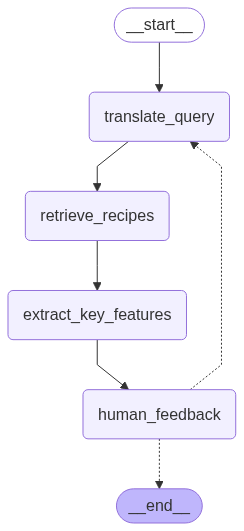

In [ ]:
builder = StateGraph(RecipeState) # Graph is initialized with the RecipeState class

builder.add_node("translate_query", QueryTranslator.translate)
builder.add_node("retrieve_recipes", RecipeRetriever.retrieve)
builder.add_node("extract_key_features", RecipeKeyFeatures.extract)
builder.add_node("human_feedback", HumanFeedback.refine)

builder.add_edge(START, "translate_query")
builder.add_edge("translate_query", "retrieve_recipes")
builder.add_edge("retrieve_recipes", "extract_key_features")
builder.add_edge("extract_key_features", "human_feedback")

# else we finalize.
builder.add_conditional_edges("human_feedback", Satisfaction.recipe_satisfaction , ["translate_query", END])

builder.executor = builder.compile()


memory = MemorySaver()
# graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)
graph = builder.compile( checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))
